In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error 
from sklearn.pipeline import make_pipeline
from ipywidgets import interact

%config InlineBackend.figure_format = 'retina'

In [2]:
data = pd.read_csv('/Users/konansul/Desktop/course-ml/DATA/rock_density_xray.csv')

In [4]:
data.columns = ['Signal', 'Density']

In [7]:
data

,Signal,Density
0,72.945124,2.456548
1,14.229877,2.601719
2,36.597334,1.967004
3,9.578899,2.300439
4,21.765897,2.452374
...,...,...
295,0.700227,2.112965
296,58.586585,2.000293
297,54.674548,1.879181
298,15.162434,2.644990


<Axes: xlabel='Signal', ylabel='Density'>

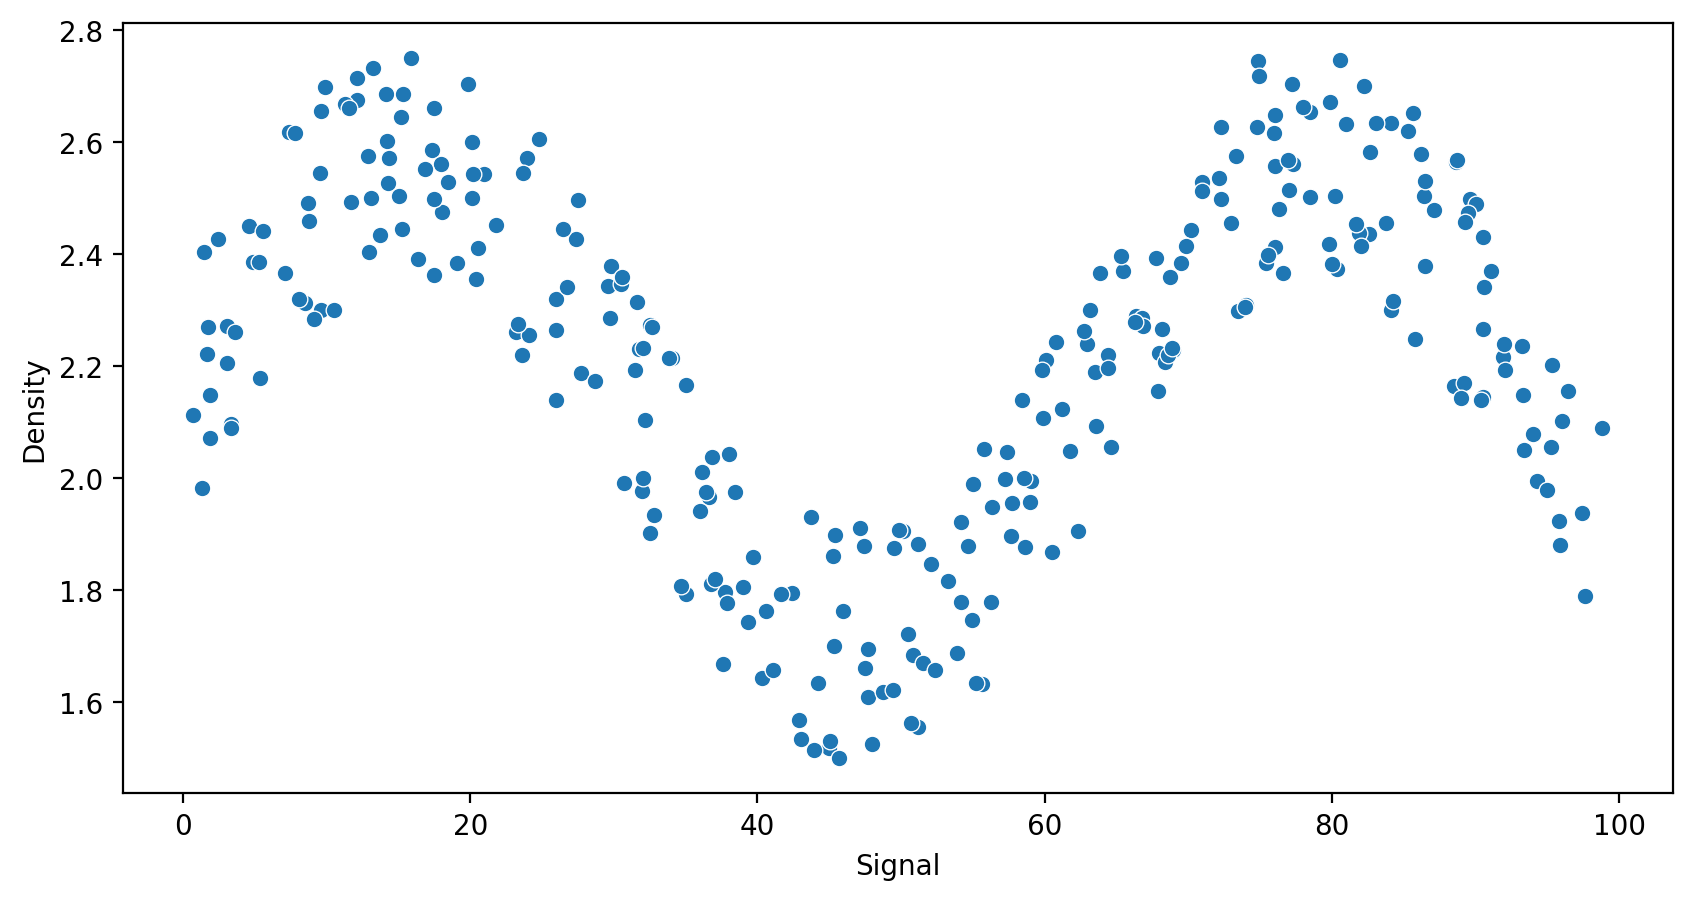

In [58]:
plt.figure(figsize = (10, 5))
sns.scatterplot(x = 'Signal', y = 'Density', data = data)

In [18]:
X = data['Signal'].values.reshape(-1, 1)

In [19]:
y = data['Density']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 101)

In [21]:
linear_model = LinearRegression()

In [22]:
linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
linear_pred = linear_model.predict(X_test)

In [24]:
linear_pred

array([2.22029657, 2.22047771, 2.22035637, 2.22034337, 2.22039737,
       2.22050555, 2.22042659, 2.22028877, 2.22034673, 2.22029714,
       2.22041506, 2.22050153, 2.22043891, 2.22042003, 2.22047022,
       2.22032403, 2.22033377, 2.22030628, 2.22035154, 2.22035373,
       2.22029266, 2.22036798, 2.22033018, 2.22030611, 2.22042754,
       2.22044019, 2.2204142 , 2.22040303, 2.22048946, 2.22047495])

In [42]:
mean_absolute_error(y_test, linear_pred)

0.2111989733186328

In [43]:
root_mean_squared_error(y_test, linear_pred)

0.25700519965846286

In [64]:
signal = np.arange(0, 100)

In [65]:
signal_pred = linear_model.predict(signal.reshape(-1, 1))

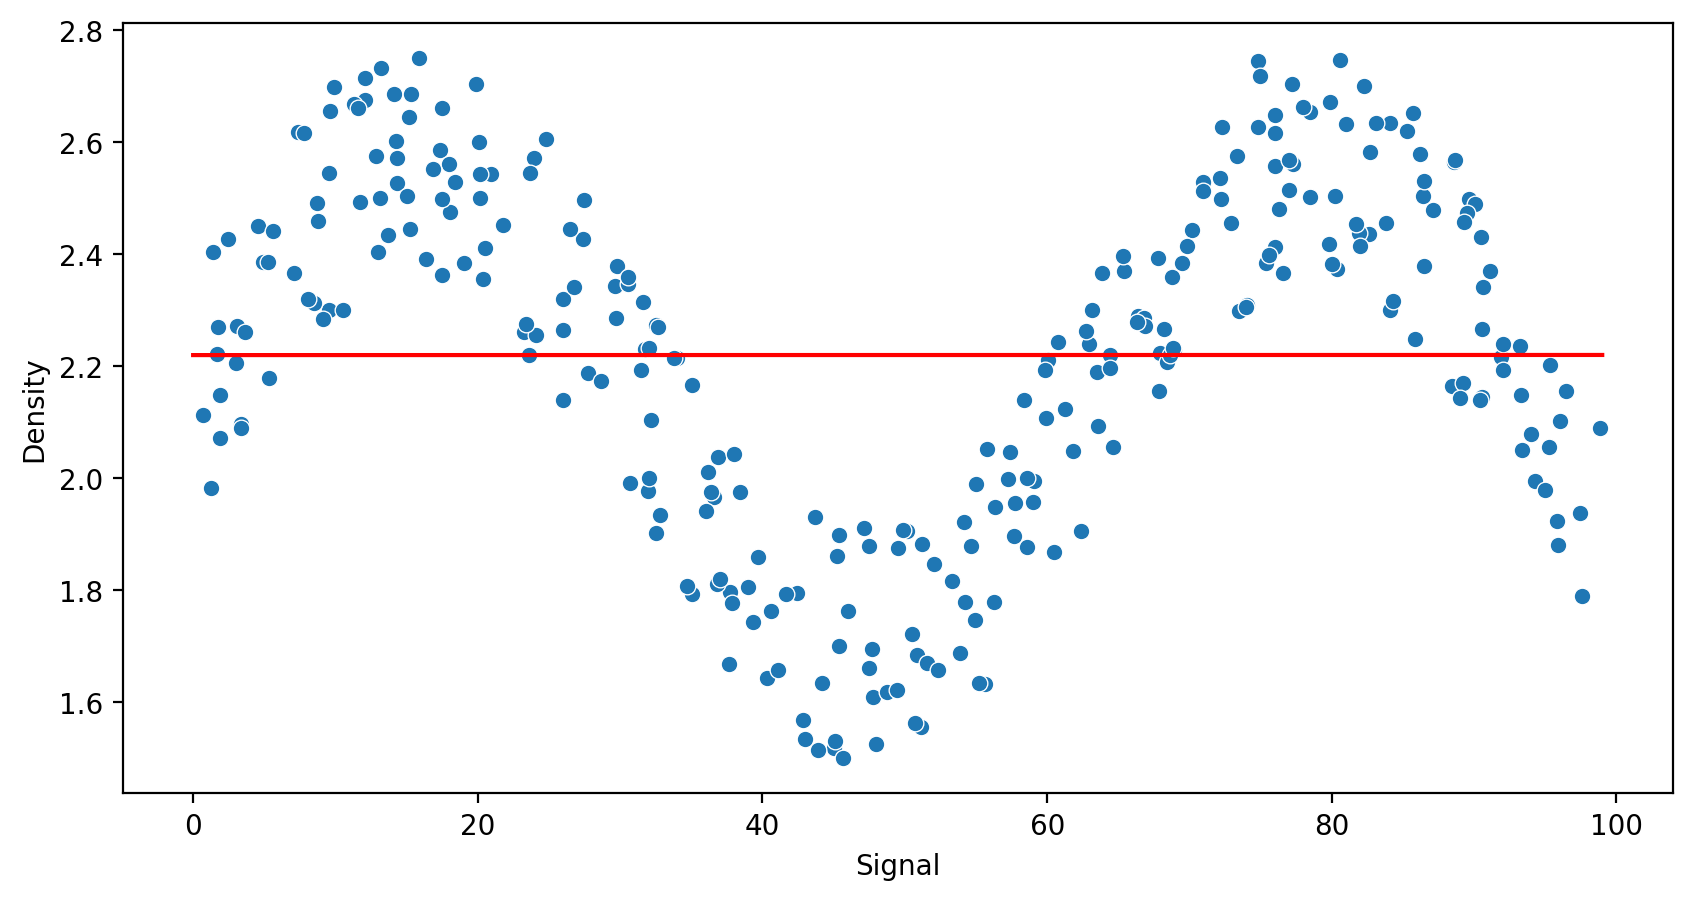

In [67]:
plt.figure(figsize = (10, 5))
sns.scatterplot(x = 'Signal', y = 'Density', data = data)
plt.plot(signal, signal_pred, color = 'red')

In [79]:
def model_test(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    
    model_pred = model.predict(X_test)
    MAE = mean_absolute_error(y_test, model_pred)
    RMSE = root_mean_squared_error(y_test, model_pred)
    print(f'MAE: {MAE}')
    print(f'RMSE: {RMSE}')
    
    model_signal = np.arange(0, 100)
    model_signal_pred = model.predict(signal.reshape(-1, 1))
    plt.figure(figsize = (10, 5))
    sns.scatterplot(x = 'Signal', y = 'Density', data = data)
    plt.plot(model_signal,  model_signal_pred, color = 'red')

MAE: 0.2111989733186328
RMSE: 0.25700519965846286


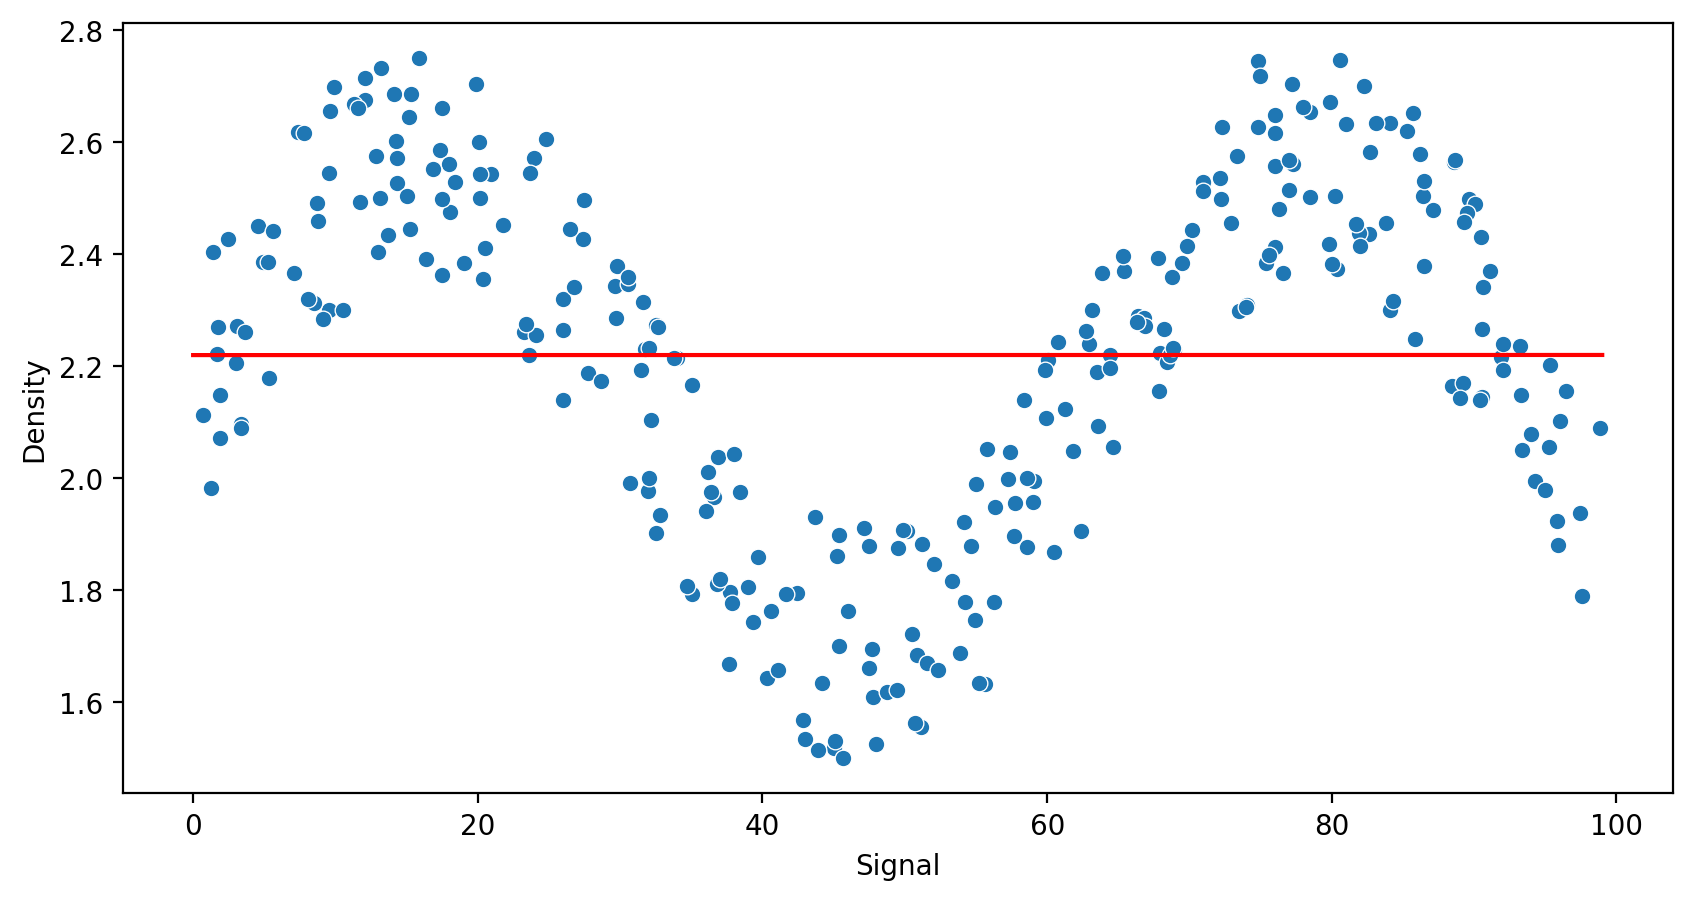

In [80]:
model = LinearRegression()
model_test(model, X_train, y_train, X_test, y_test)

In [81]:
pipeline = make_pipeline(PolynomialFeatures(degree = 2), LinearRegression())

MAE: 0.22903105443511165
RMSE: 0.2817309563725552


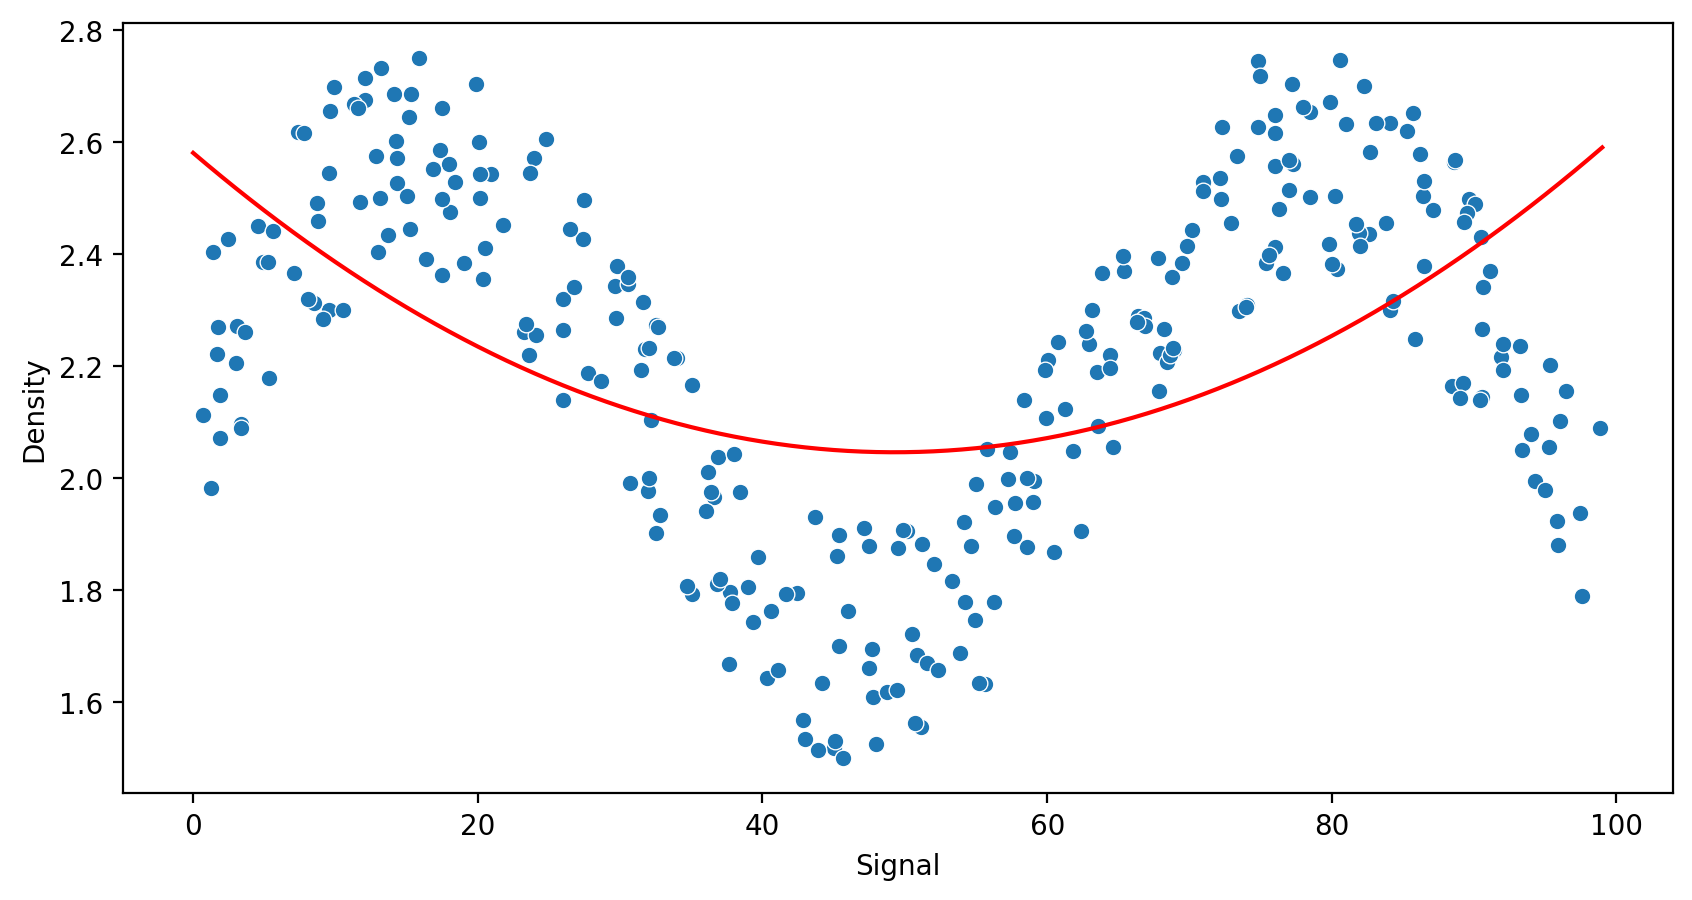

In [82]:
model_test(pipeline, X_train, y_train, X_test, y_test)

In [99]:
def plot_poly(degree):
    plt.figure(figsize = (10, 5))
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train.reshape(-1, 1), y_train.values)
    
    x_line = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
    y_line = model.predict(x_line)

    model_pred = model.predict(X_test)
    MAE = mean_absolute_error(y_test, model_pred)
    RMSE = root_mean_squared_error(y_test, model_pred)
    print(f'MAE: {MAE}')
    print(f'RMSE: {RMSE}')

    model_signal = np.arange(0, 100)
    model_signal_pred = model.predict(signal.reshape(-1, 1))
    sns.scatterplot(x = 'Signal', y = 'Density', data = data)
    plt.plot(model_signal,  model_signal_pred, color = 'red')
    plt.grid(1)
    plt.show()

interact(plot_poly, degree=(1, 50))

interactive(children=(IntSlider(value=25, description='degree', max=50, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_poly(degree)>

In [96]:
def plot_poly(degree):
    plt.figure(figsize = (10, 5))
    model = KNeighborsRegressor(n_neighbors = degree)
    model.fit(X_train.reshape(-1, 1), y_train.values)
    
    x_line = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
    y_line = model.predict(x_line)

    model_pred = model.predict(X_test)
    MAE = mean_absolute_error(y_test, model_pred)
    RMSE = root_mean_squared_error(y_test, model_pred)
    print(f'MAE: {MAE}')
    print(f'RMSE: {RMSE}')

    model_signal = np.arange(0, 100)
    model_signal_pred = model.predict(signal.reshape(-1, 1))
    sns.scatterplot(x = 'Signal', y = 'Density', data = data)
    plt.plot(model_signal,  model_signal_pred, color = 'red')
    plt.grid(1)
    plt.show()

interact(plot_poly, degree=(1, 100))

interactive(children=(IntSlider(value=50, description='degree', min=1), Output()), _dom_classes=('widget-inter…

<function __main__.plot_poly(degree)>

MAE: 0.11877297474442386
RMSE: 0.15234870286353372


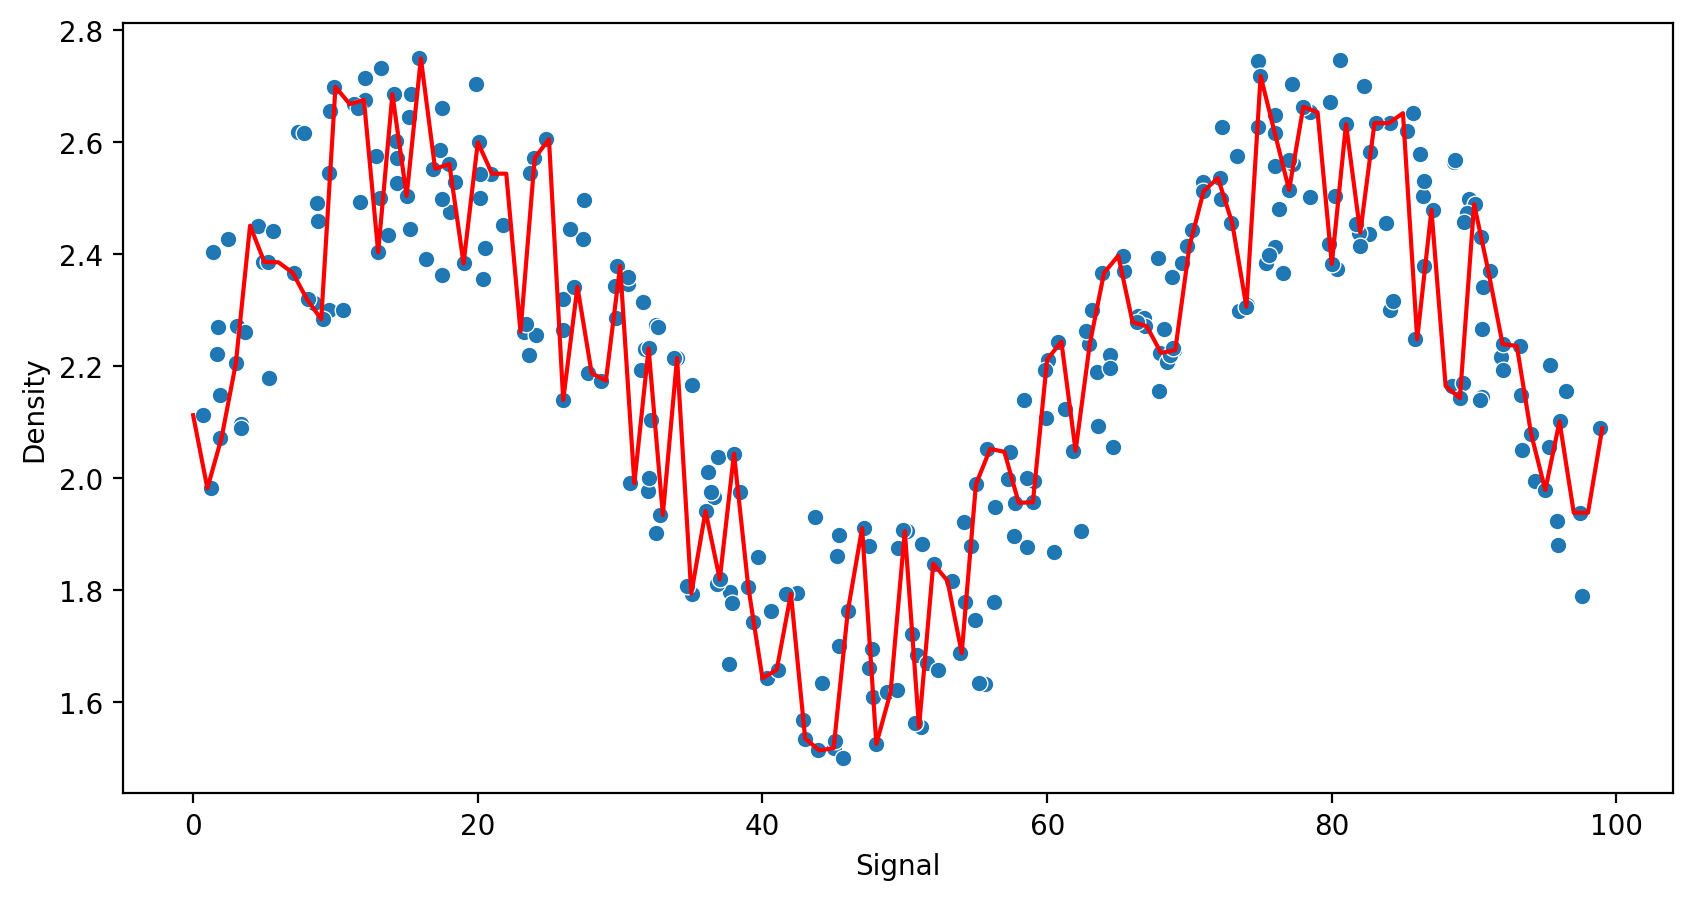

In [102]:
tree_model = DecisionTreeRegressor()
model_test(tree_model, X_train, y_train, X_test, y_test)

MAE: 0.12019666627239366
RMSE: 0.13501323391230885


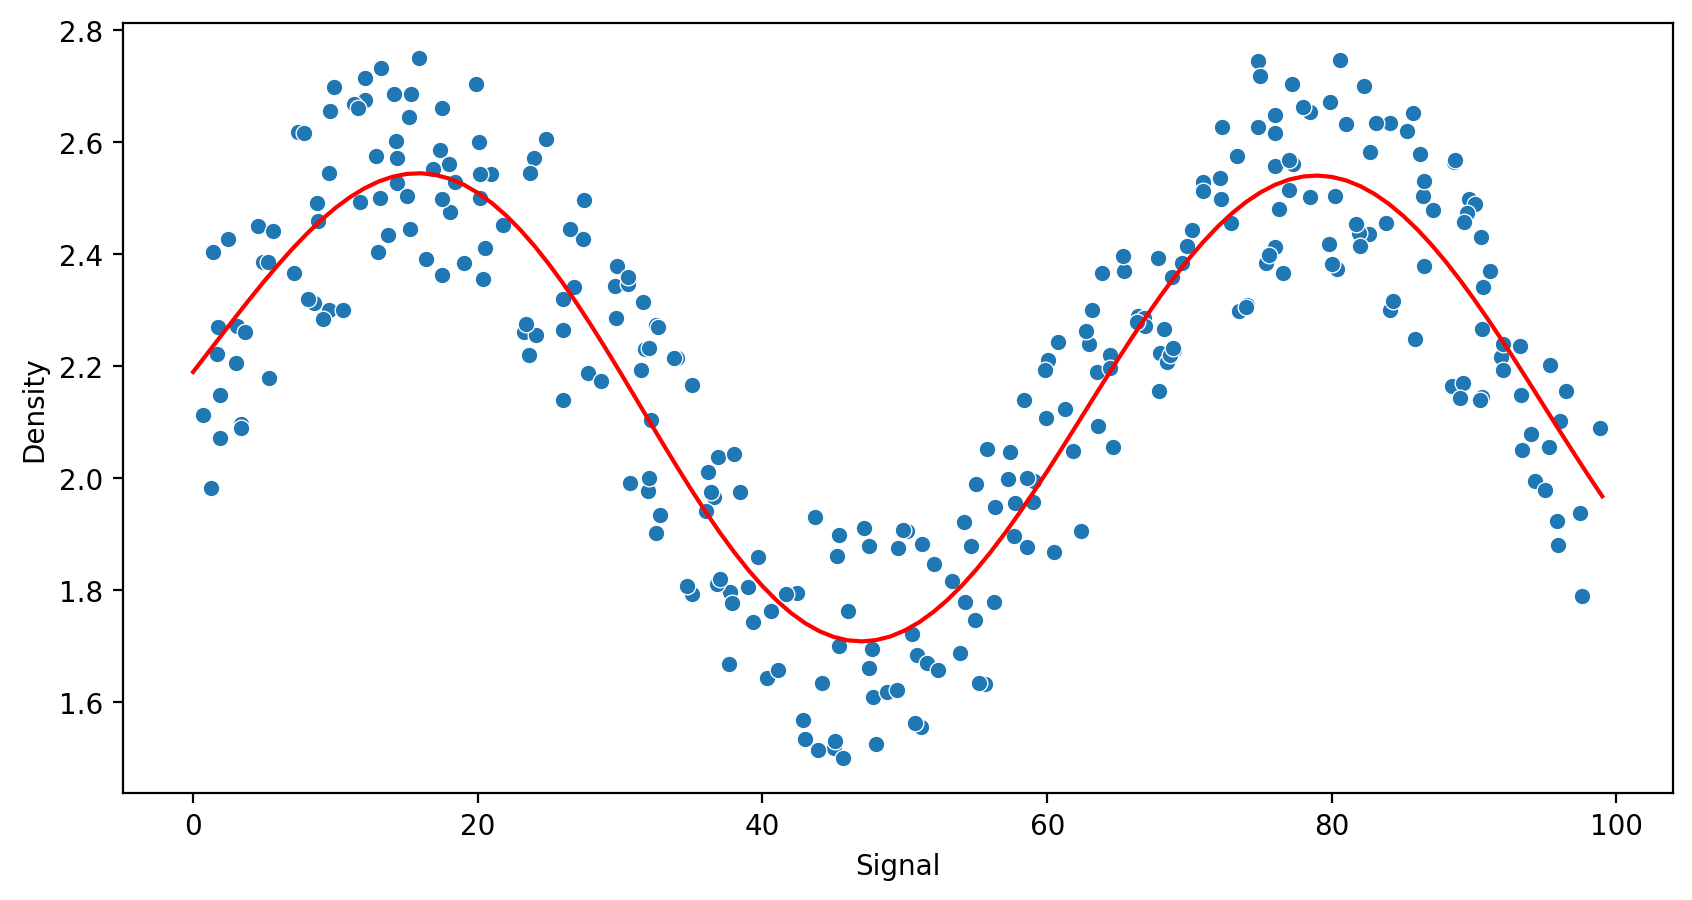

In [106]:
vector_model = SVR()
model_test(vector_model, X_train, y_train, X_test, y_test)

In [108]:
forest_model = RandomForestRegressor()

MAE: 0.11087798492896996
RMSE: 0.13184582757953076


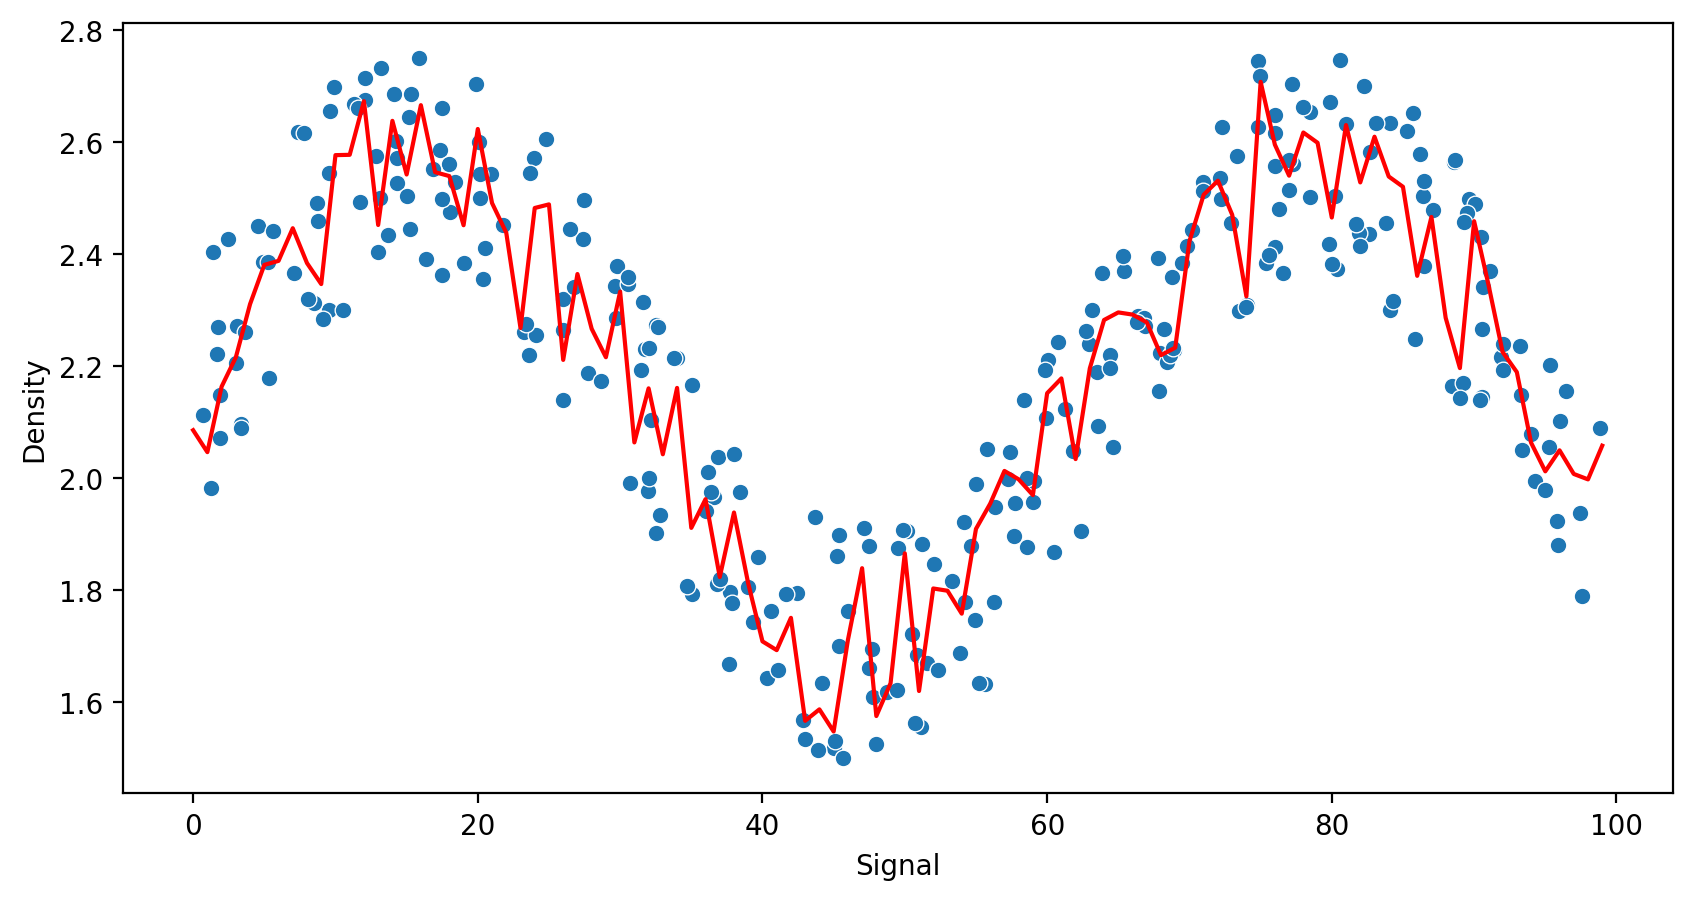

In [109]:
model_test(forest_model, X_train, y_train, X_test, y_test)

In [110]:
def plot_poly(degree):
    plt.figure(figsize = (10, 5))
    model = RandomForestRegressor(n_estimators = degree)
    model.fit(X_train.reshape(-1, 1), y_train.values)
    
    x_line = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
    y_line = model.predict(x_line)

    model_pred = model.predict(X_test)
    MAE = mean_absolute_error(y_test, model_pred)
    RMSE = root_mean_squared_error(y_test, model_pred)
    print(f'MAE: {MAE}')
    print(f'RMSE: {RMSE}')

    model_signal = np.arange(0, 100)
    model_signal_pred = model.predict(signal.reshape(-1, 1))
    sns.scatterplot(x = 'Signal', y = 'Density', data = data)
    plt.plot(model_signal,  model_signal_pred, color = 'red')
    plt.grid(1)
    plt.show()

interact(plot_poly, degree=(1, 100))

interactive(children=(IntSlider(value=50, description='degree', min=1), Output()), _dom_classes=('widget-inter…

<function __main__.plot_poly(degree)>

In [ ]:
#GradientBoostingRegressor, AdaBoostRegressor

MAE: 0.11318284854800688
RMSE: 0.13294148649584664


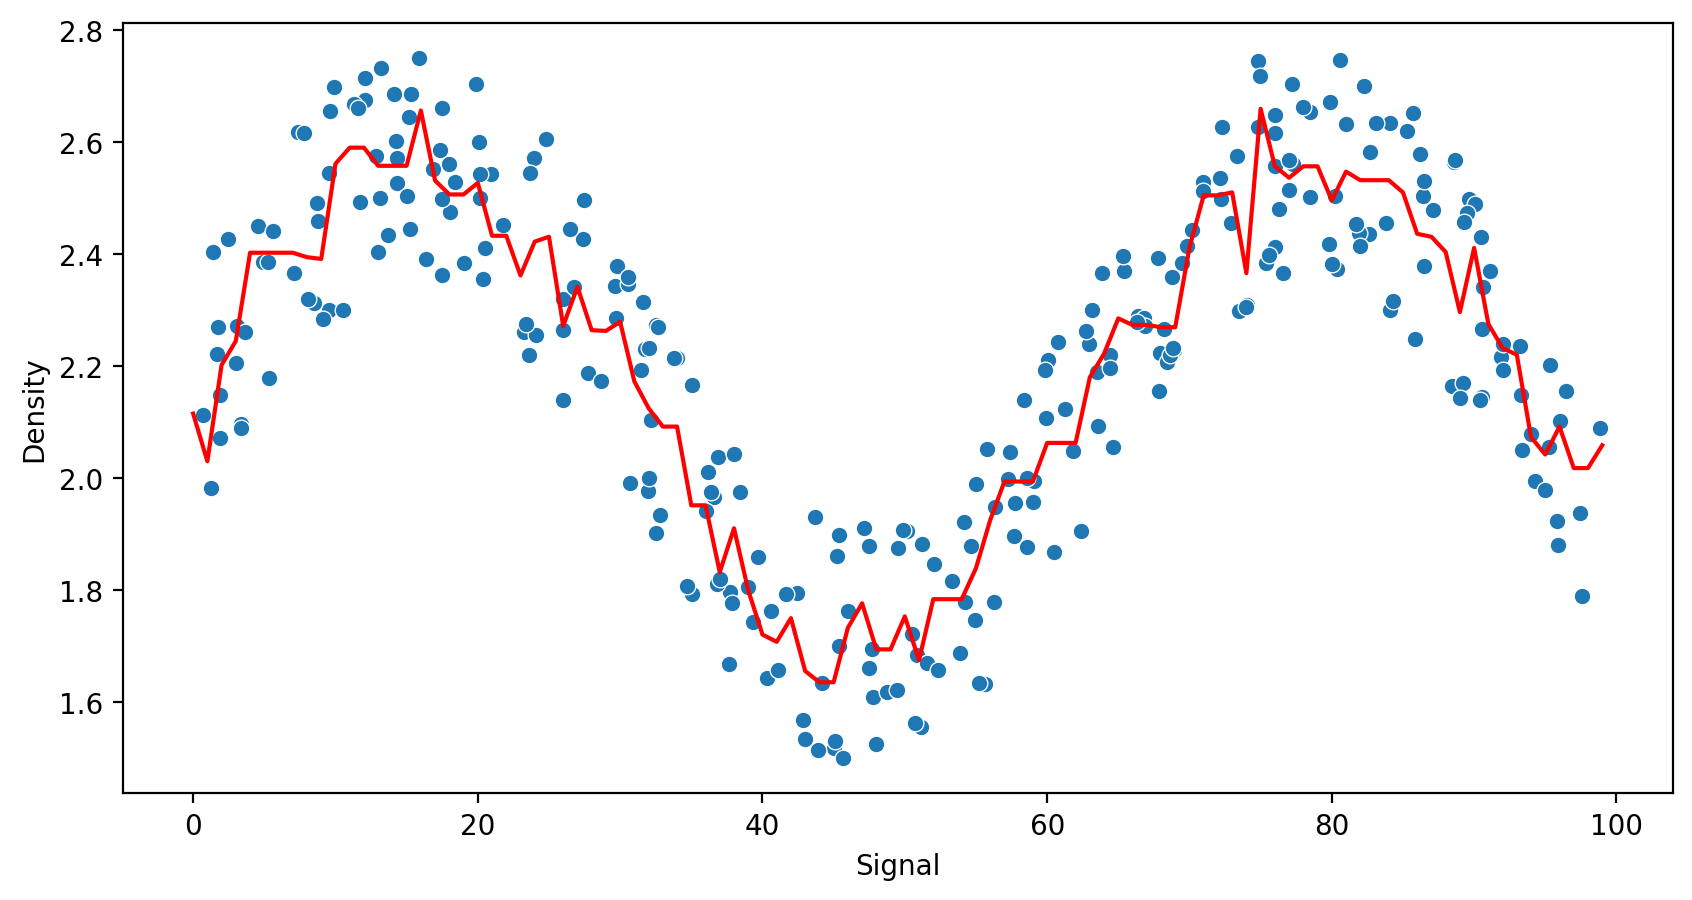

In [114]:
boosted_model = GradientBoostingRegressor()
model_test(boosted_model, X_train, y_train, X_test, y_test)

MAE: 0.12264924408224388
RMSE: 0.1424704209333406


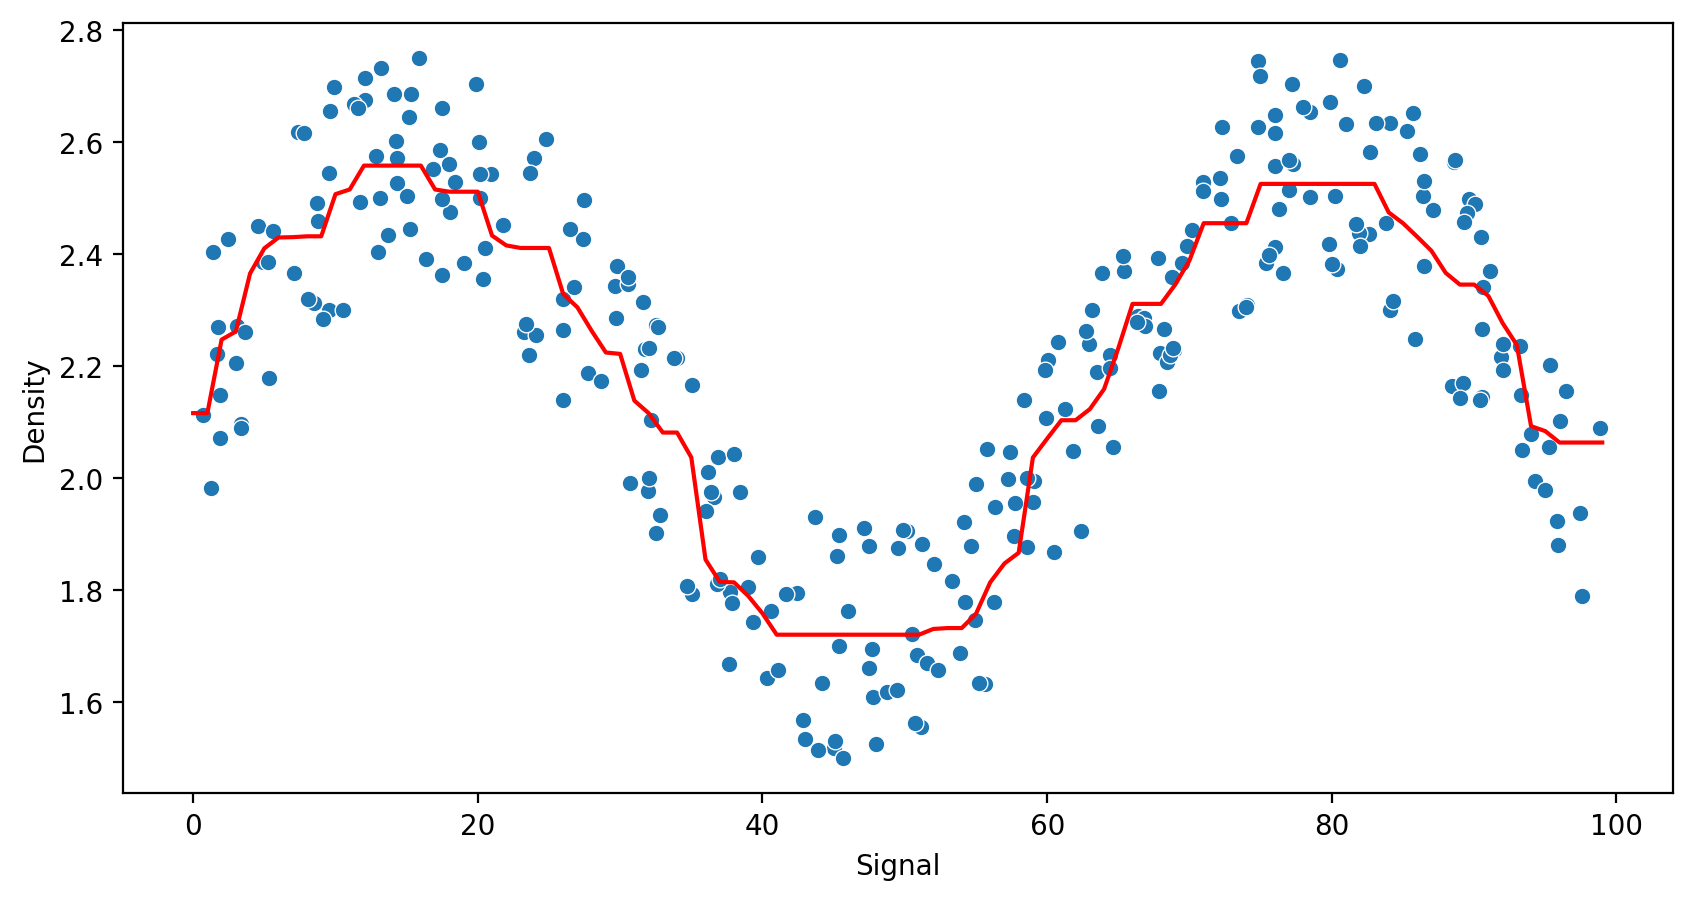

In [115]:
ada_model = AdaBoostRegressor()
model_test(ada_model, X_train, y_train, X_test, y_test)